<a href="https://colab.research.google.com/github/StephanyMejia25/MejiaStephany2524022017/blob/main/archivos/AnalisisdeAgrupacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# 1. Cargar datos
url= "https://raw.githubusercontent.com/StephanyMejia25/MejiaStephany2524022017/refs/heads/main/archivos/clave_A_agrupacion.csv"
df = pd.read_csv(url)
df.head()


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,A-R0009,18,447,0.55,21.04,5.46,2,7
1,A-R0023,22,624,3.82,33.36,7.31,2,1
2,A-R0099,34,1091,8.12,105.43,7.51,1,21
3,A-R0159,46,1365,10.62,158.81,7.74,12,43
4,A-R0221,52,570,3.82,32.46,4.63,5,15


In [3]:
# Revisión inicial
print("Dimensiones del dataset:")
print(df.shape)

print("\nPrimeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nEstadística descriptiva:")
print(df.describe())

Dimensiones del dataset:
(230, 8)

Primeras filas:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     A-R0009    18       447            0.55           21.04          5.46   
1     A-R0023    22       624            3.82           33.36          7.31   
2     A-R0099    34      1091            8.12          105.43          7.51   
3     A-R0159    46      1365           10.62          158.81          7.74   
4     A-R0221    52       570            3.82           32.46          4.63   

   reclamos  antiguedad_meses  
0         2                 7  
1         2                 1  
2         1                21  
3        12                43  
4         5                15  

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       230 non-null    object 
 1   edad      

In [4]:
# Revisión de valores atípicos
variables_numericas = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']

print("\nRevisión de valores atípicos:")
for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviación estándar:", round(desviacion, 2))
    print("Límite inferior:", round(limite_inferior, 2))
    print("Límite superior:", round(limite_superior, 2))
    print("Cantidad de valores atípicos:", len(atipicos))
    print("-" * 40)


Revisión de valores atípicos:
Variable: edad
Media: 33.79
Desviación estándar: 9.94
Límite inferior: 13.91
Límite superior: 53.66
Cantidad de valores atípicos: 5
----------------------------------------
Variable: ingresos
Media: 936.96
Desviación estándar: 398.11
Límite inferior: 140.73
Límite superior: 1733.19
Cantidad de valores atípicos: 5
----------------------------------------
Variable: frecuencia_uso
Media: 5.49
Desviación estándar: 2.96
Límite inferior: -0.44
Límite superior: 11.41
Cantidad de valores atípicos: 0
----------------------------------------
Variable: gasto_promedio
Media: 75.55
Desviación estándar: 43.66
Límite inferior: -11.77
Límite superior: 162.88
Cantidad de valores atípicos: 5
----------------------------------------
Variable: satisfaccion
Media: 6.91
Desviación estándar: 1.89
Límite inferior: 3.12
Límite superior: 10.69
Cantidad de valores atípicos: 4
----------------------------------------
Variable: reclamos
Media: 2.47
Desviación estándar: 2.02
Límite in

aplicar K-Means y Asignar Clusters

Una vez que hemos determinado el número óptimo de clusters (observando el gráfico del método del codo, un valor de K=3 o K=4 parece razonable), procederemos a aplicar el algoritmo K-Means con este número de clusters a nuestros datos escalados. Luego, asignaremos el cluster resultante a cada fila del DataFrame original.

In [8]:
# Asumiendo k=3 como número óptimo de clusters basado en el método del codo (ajusta este valor si el gráfico sugiere otro)
optimal_k = 3

kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_scaled)

# Agregar la columna de clusters al DataFrame original
df['Cluster'] = clusters

print("Primeras 5 filas del DataFrame con la columna de Cluster:")
print(df.head())

Primeras 5 filas del DataFrame con la columna de Cluster:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     A-R0009    18       447            0.55           21.04          5.46   
1     A-R0023    22       624            3.82           33.36          7.31   
2     A-R0099    34      1091            8.12          105.43          7.51   
3     A-R0159    46      1365           10.62          158.81          7.74   
4     A-R0221    52       570            3.82           32.46          4.63   

   reclamos  antiguedad_meses  Cluster  
0         2                 7        1  
1         2                 1        1  
2         1                21        0  
3        12                43        2  
4         5                15        1  


Visualizar los Grupos (Clusters)

Para visualizar los clusters, podemos reducir la dimensionalidad de nuestros datos utilizando Análisis de Componentes Principales (PCA) a 2 o 3 dimensiones. Esto nos permitirá graficar los clusters en un espacio 2D o 3D. También podemos usar gráficos de dispersión de pares para las características originales, coloreando por cluster, para ver las separaciones.

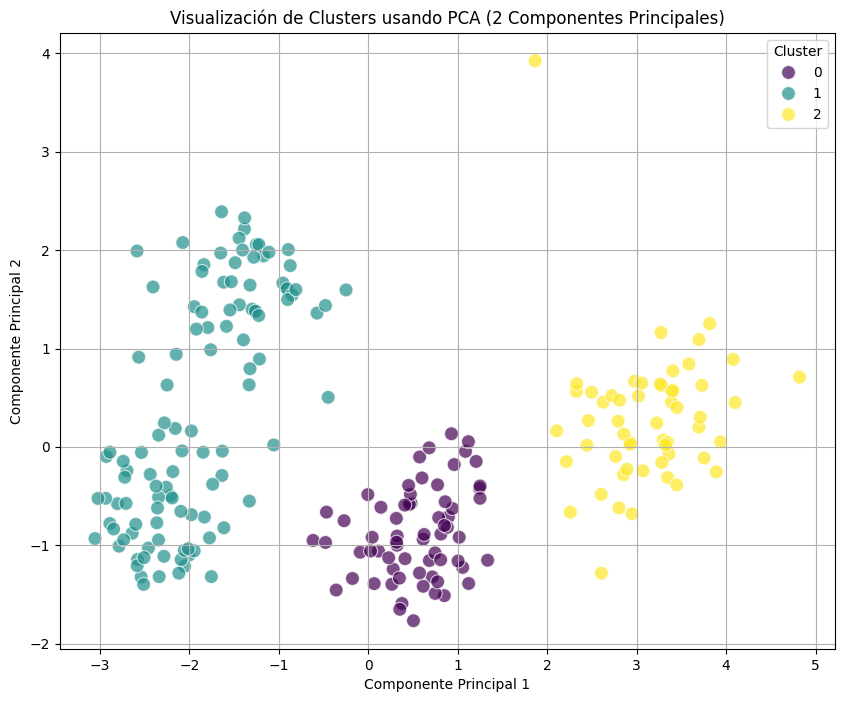

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100, alpha=0.7)
plt.title('Visualización de Clusters usando PCA (2 Componentes Principales)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

Visualización de Distribuciones por Cluster (Pairplot)

Un pairplot nos permite ver las relaciones entre las características y cómo se distribuyen dentro de cada cluster. Esto puede ser muy útil para entender las características distintivas de cada grupo.

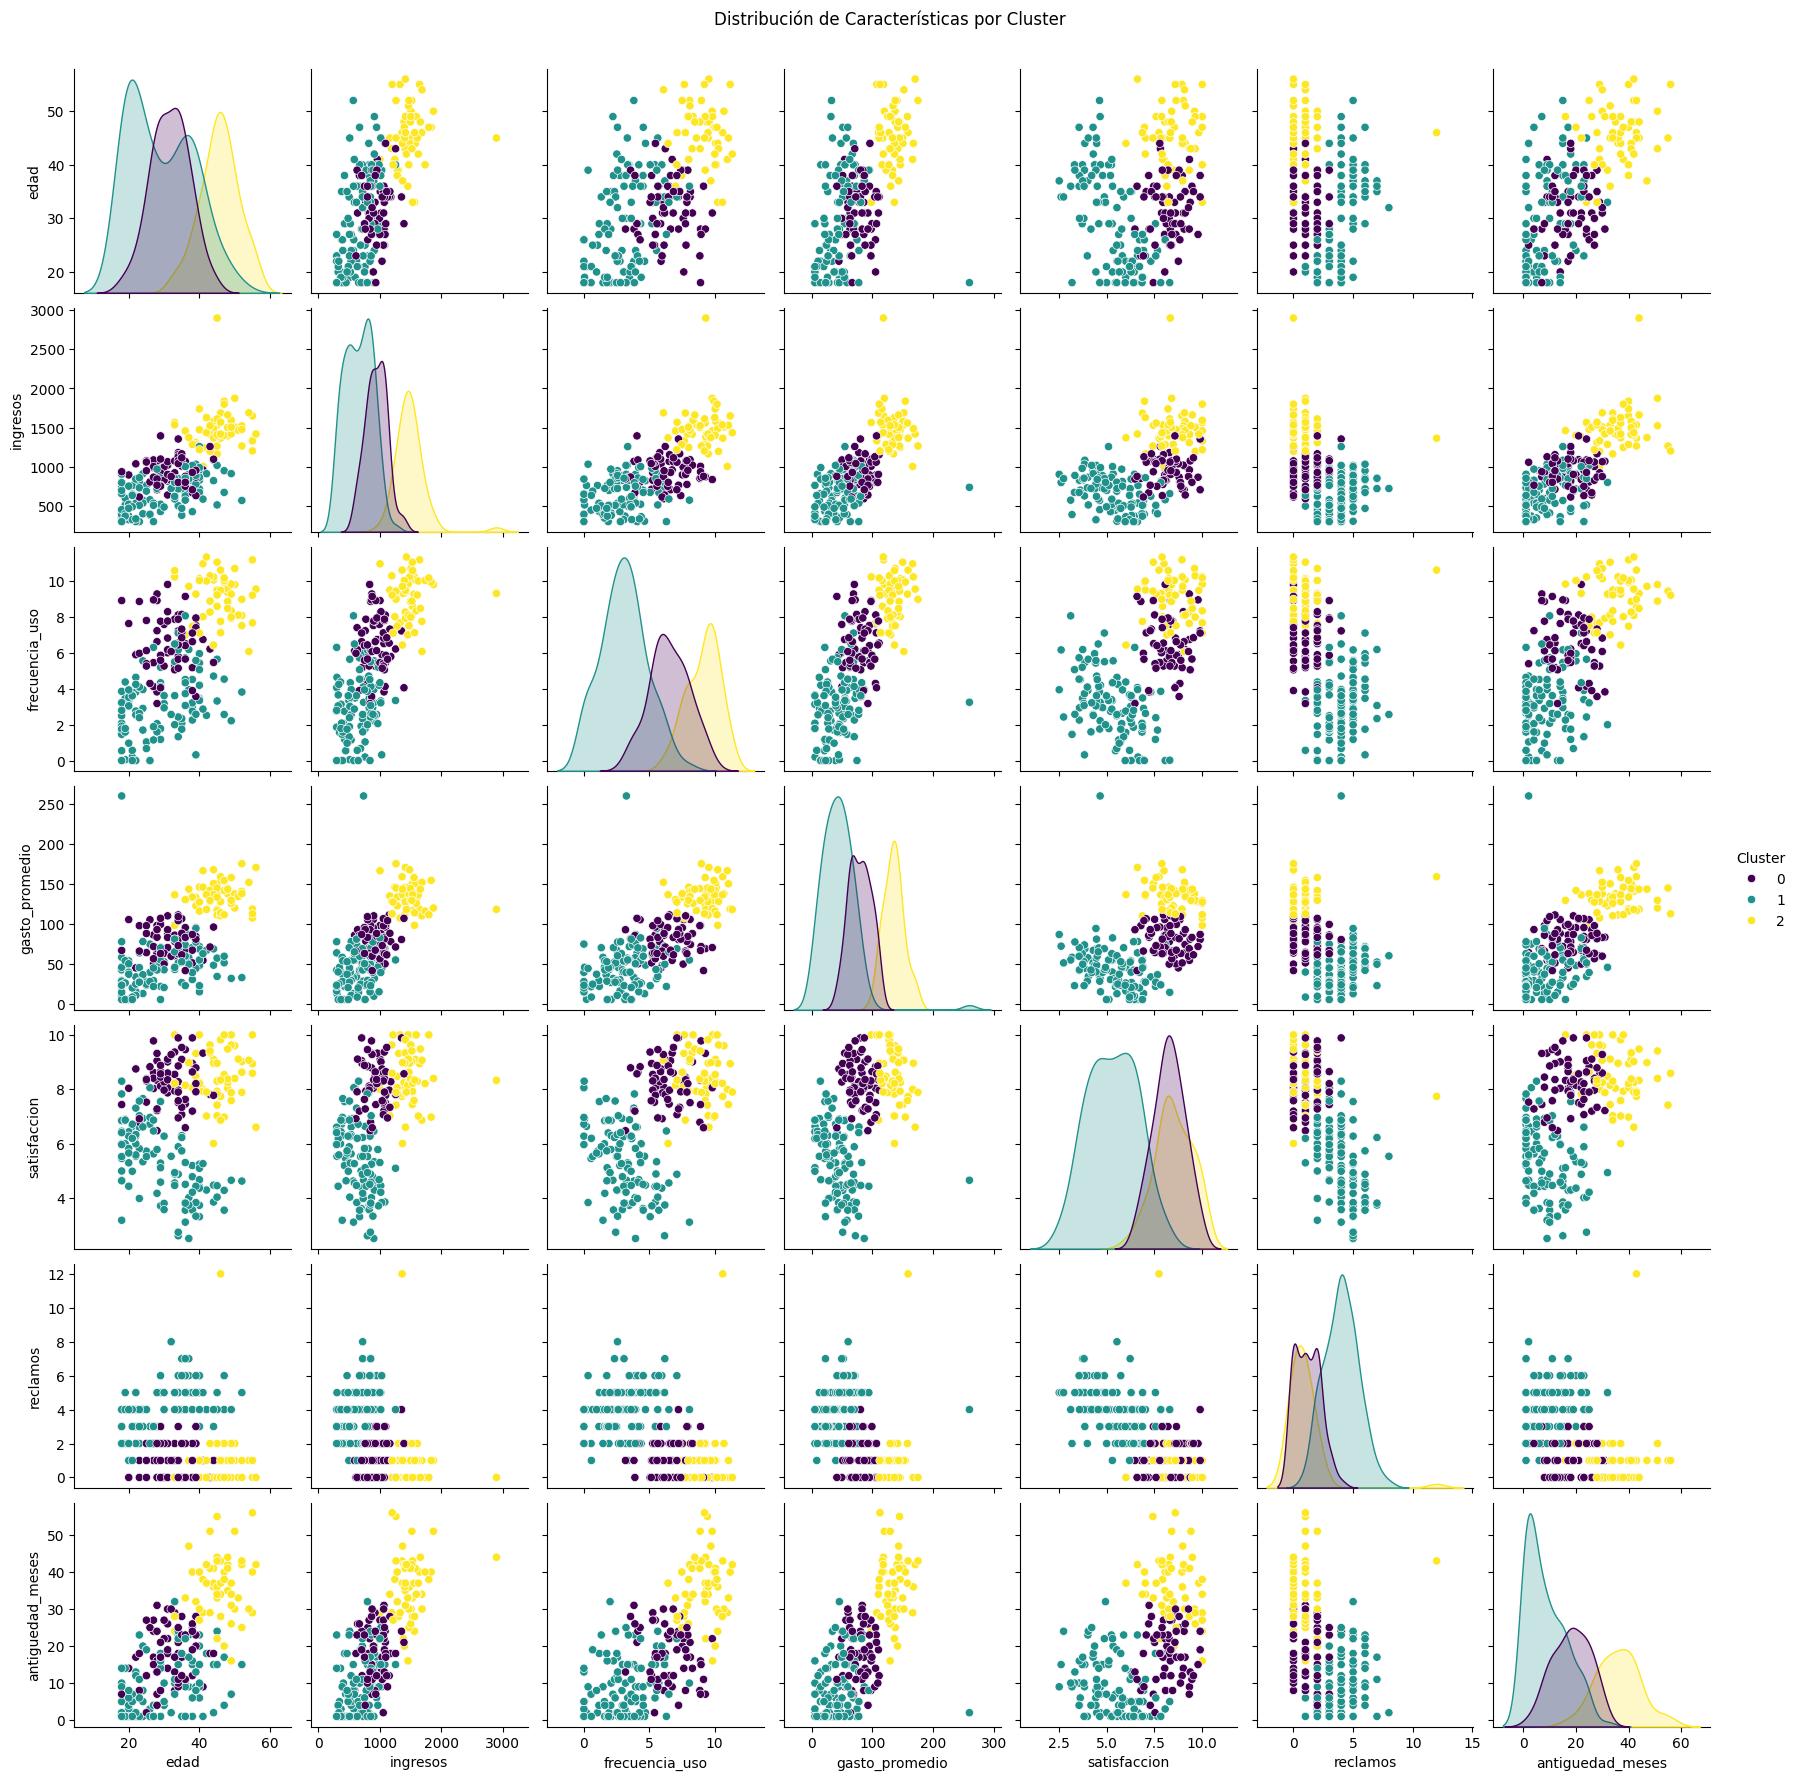

In [10]:
sns.pairplot(df, hue='Cluster', vars=features, palette='viridis')
plt.suptitle('Distribución de Características por Cluster', y=1.02) # Ajusta el título para que no se superponga
plt.show()

In [5]:
# Imputar el valor faltante en 'satisfaccion' con la media
df['satisfaccion'].fillna(df['satisfaccion'].mean(), inplace=True)
print("Valores nulos después de la imputación:")
print(df.isnull().sum())

Valores nulos después de la imputación:
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        0
reclamos            0
antiguedad_meses    0
dtype: int64


/tmp/ipykernel_2002/3079552447.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['satisfaccion'].fillna(df['satisfaccion'].mean(), inplace=True)


In [6]:
from sklearn.preprocessing import StandardScaler

# Seleccionar las características para el agrupamiento
features = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']
X = df[features]

# Escalar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Primeras 5 filas de las características escaladas:")
print(X_scaled[:5])

Primeras 5 filas de las características escaladas:
[[-1.59223316 -1.23339001 -1.66965117 -1.25123755 -0.76869111 -0.23285598
  -0.81606042]
 [-1.18880311 -0.78782375 -0.56344366 -0.96846208  0.21350213 -0.23285598
  -1.26797189]
 [ 0.02148704  0.38776632  0.89120231  0.68572852  0.31968518 -0.72875298
   0.23839967]
 [ 1.23177718  1.07751296  1.7369267   1.91093588  0.44179569  4.726114
   1.89540839]
 [ 1.83692225 -0.92375922 -0.56344366 -0.98911938 -1.20935078  1.25483501
  -0.21351179]]


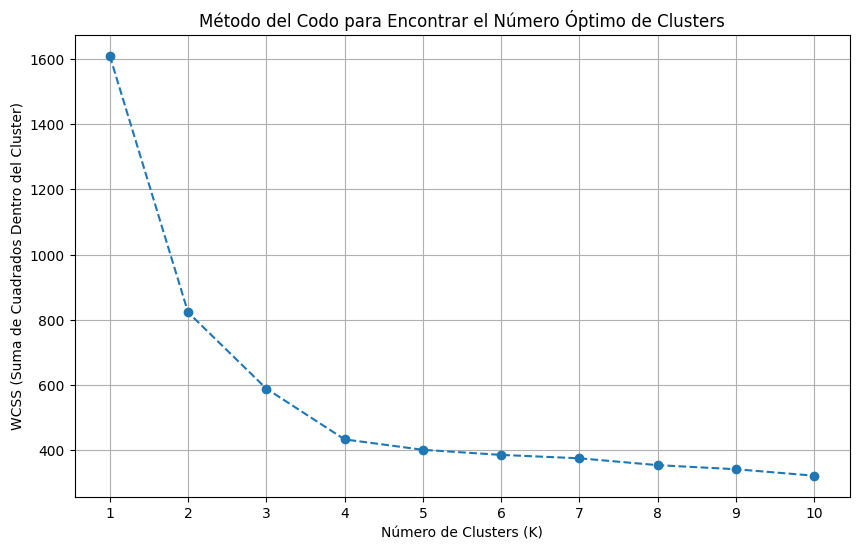

In [7]:
from sklearn.cluster import KMeans

wcss = []
max_clusters = 10

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init for modern scikit-learn
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para Encontrar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Suma de Cuadrados Dentro del Cluster)')
plt.grid(True)
plt.xticks(range(1, max_clusters + 1))
plt.show()